In [2]:
!pip install faker --quiet

import random
import re
import pandas as pd
from faker import Faker
from typing import List, Tuple, Set


fake = Faker()
Faker.seed(42)
random.seed(42)


JOB_KEYWORDS = {
    "Software Engineer": [
        "Java", "C++", "Python", "Go", "Rust", "Git", "System Design", "Algorithms",
        "Data Structures", "Docker", "Kubernetes", "CI/CD", "Microservices", "REST APIs",
        "HTTP", "Multithreading", "Concurrency", "OAuth", "PostgreSQL", "MySQL", "NoSQL",
        "Testing", "Unit Tests", "TDD", "Design Patterns", "Scalable Systems"
    ],
    "Product Manager": [
        "Roadmap", "Stakeholder Management", "Analytics", "Agile", "Scrum", "A/B Testing",
        "Wireframes", "User Stories", "OKRs", "KPIs", "Prioritization", "Product Strategy",
        "Go-to-market", "Market Research", "Customer Interviews", "Feature Scoping",
        "Revenue", "Monetization", "Product Metrics", "User Feedback", "Competitive Analysis"
    ],
    "Designer": [
        "Figma", "Sketch", "Adobe XD", "Photoshop", "Illustrator", "InDesign", "Prototyping",
        "UX Research", "User Testing", "Information Architecture", "Visual Design",
        "Interaction Design", "Design Systems", "Accessibility", "Typography",
        "Branding", "Wireframing", "User Flows", "High-fidelity", "Responsive Design"
    ]
}
ALL_CATEGORIES = list(JOB_KEYWORDS.keys())


def make_email(name: str) -> str:
    username = re.sub(r'[^a-z0-9]', '.', name.lower())
    username = re.sub(r'\.+', '.', username).strip('.')
    domain = random.choice(["gmail.com", "hotmail.com", "example.com", "outlook.com", "icloud.com"])
    return f"{username}.{random.randint(1,9999)}@{domain}"

def truncate_to_word_limit(text: str, max_words: int = 80) -> str:
    words = text.split()
    if len(words) <= max_words:
        return text
    return " ".join(words[:max_words])

def pick_non_target_keywords(target: str, k: int) -> List[str]:
    others = [kw for cat, kws in JOB_KEYWORDS.items() if cat != target for kw in kws]
    if len(others) == 0:
        others = OTHER_PHRASES
    return random.sample(others, min(k, len(others)))

SUMMARY_TEMPLATES = [
    "Experienced {} with strong background in {} and {}.",
    "{} specializing in {} with experience delivering {}.",
    "Practical {} skilled in {} and {}.",
    "{} with {} years of experience in {} and {}.",
    "Passionate {} focusing on {} and {} to deliver product impact.",
    "Research-oriented {} experienced in {} and {} for applied outcomes.",
    "Creative {} who leverages {} and {} to solve user problems."
]

WORK_TEMPLATES = [
    "Developed {} to improve {}.",
    "Led a team that implemented {} using {}.",
    "Conducted {} and reported findings in {}.",
    "Built production-ready {} and integrated with {}.",
    "Designed {} focused on {}.",
    "Performed {} for product improvements and {}.",
    "Managed {} and coordinated with {} stakeholders.",
    "Architected {} to scale {} across services.",
    "Implemented {} following {} best practices.",
    "Optimized {} achieving {} improvement in {}.",
    "Designed experiments on {} and analyzed {}.",
    "Prototyped {} and tested with {} users.",
    "Authored {} submitted to {}.",
    "Automated {} in the {} pipeline."
]

BULLET_ACTIONS = [
    "Improved", "Reduced", "Increased", "Automated", "Published", "Designed",
    "Implemented", "Measured", "Validated", "Scaled", "Refactored"
]
BULLET_METRICS = [
    "performance", "latency", "accuracy", "user conversions", "throughput",
    "citation count", "engagement", "retention", "test coverage"
]
OTHER_PHRASES = [
    "cross-functional teams", "scalable systems", "large datasets", "user research",
    "experimental setups", "cloud infrastructure", "CI pipelines", "data pipelines",
    "mobile platforms", "web platforms", "stakeholder feedback", "production metrics"
]


def fill_template_with_args(tmpl: str, primary: str, secondary: str, tertiary: str) -> str:
    n = tmpl.count("{}")
    if n == 0:
        return tmpl
    if n == 1:
        return tmpl.format(primary)
    if n == 2:
        return tmpl.format(primary, secondary)
    # n >= 3
    extras = [primary, secondary, tertiary]
    # if template needs more than 3, add random keywords/phrases
    while len(extras) < n:
        extras.append(random.choice(sum(JOB_KEYWORDS.values(), []) + OTHER_PHRASES))
    return tmpl.format(*extras[:n])

def generate_resume_text(
    target_category: str,
    positive: bool,
    max_words: int = 80,
    min_sentences: int = 2,
    max_sentences: int = 5
) -> Tuple[str, List[str]]:
    sentences = []
    num_sentences = random.randint(min_sentences, max_sentences)

    if positive:
        n_kw = random.randint(1, 4)
        kws = random.sample(JOB_KEYWORDS[target_category], min(n_kw, len(JOB_KEYWORDS[target_category])))
    else:
        if random.random() < 0.15:
            kws = pick_non_target_keywords(target_category, random.randint(1, 2))
        else:
            kws = pick_non_target_keywords(target_category, random.randint(1, 4))

    keywords_used = kws.copy()

    for i in range(num_sentences):
        if i == 0:
            k1 = random.choice(kws)
            k2_candidates = [kw for kw in sum(JOB_KEYWORDS.values(), []) if kw not in kws] + OTHER_PHRASES
            k2 = random.choice(k2_candidates)
            tmpl = random.choice(SUMMARY_TEMPLATES)
            if "{} with {} years" in tmpl or random.random() < 0.2:
                years = f"{random.randint(1,12)}+ years"
                sentence = fill_template_with_args(tmpl, target_category, years, k1)
            else:
                sentence = fill_template_with_args(tmpl, target_category, k1, k2)
        else:
            tmpl = random.choice(WORK_TEMPLATES)
            a = random.choice(kws)
            other = random.choice(OTHER_PHRASES + [random.choice(sum(JOB_KEYWORDS.values(), []))])
            # tertiary filler
            tertiary = random.choice(sum(JOB_KEYWORDS.values(), []) + OTHER_PHRASES)
            sentence = fill_template_with_args(tmpl, a, other, tertiary)
        sentences.append(sentence)

    # bullets
    bullets = []
    num_bullets = random.choices([0,1,2,3], weights=[0.35,0.35,0.2,0.1])[0]
    for _ in range(num_bullets):
        action = random.choice(BULLET_ACTIONS)
        metric = random.choice(BULLET_METRICS)
        by = random.choice(["by 20%", "by 30%", "two-fold", "measurably", "substantially", "from baseline"])
        kw = random.choice(keywords_used + OTHER_PHRASES + [random.choice(sum(JOB_KEYWORDS.values(), []))])
        bullets.append(f"{action} {metric} {by} using {kw}.")

    text_parts = sentences + bullets
    text = " ".join(text_parts)
    text = truncate_to_word_limit(text, max_words)
    text = re.sub(r'\s+', ' ', text).strip()
    return text, keywords_used

def generate_balanced_dataset(per_class: int = 100, enforce_unique_texts: bool = True, max_attempts_per_item: int = 50) -> pd.DataFrame:
    records = []
    seen_texts: Set[str] = set()

    for job_cat in ALL_CATEGORIES:
        for positive in [True, False]:
            produced = 0
            attempts = 0
            while produced < per_class and attempts < per_class * max_attempts_per_item:
                attempts += 1
                name = fake.name()
                email = make_email(name)
                resume_text, kws_used = generate_resume_text(job_cat, positive)
                if enforce_unique_texts and resume_text in seen_texts:
                    continue
                text_lower = resume_text.lower()
                target_kw_present = any(re.search(r'\b' + re.escape(kw.lower()) + r'\b', text_lower) for kw in JOB_KEYWORDS[job_cat])
                label = 1 if target_kw_present else 0

                if positive and label == 0:
                    continue
                if (not positive) and label == 1:
                    continue

                records.append({
                    "name": name,
                    "email": email,
                    "job_category": job_cat,
                    "resume_text": resume_text,
                    "keywords": kws_used,
                    "label": label
                })
                produced += 1
                if enforce_unique_texts:
                    seen_texts.add(resume_text)

            if produced < per_class:
                print(f"Warning: for category '{job_cat}' positive={positive} only produced {produced}/{per_class} after {attempts} attempts.")

    df = pd.DataFrame(records)
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)
    return df

print("Generating balanced dataset: 100 positives + 100 negatives per category (total expected = 1000)...")
df = generate_balanced_dataset(per_class=500)
print("Generated rows:", len(df))
print("Label distribution:\n", df['label'].value_counts())
print("Per-category counts:\n", df['job_category'].value_counts())

df['word_count'] = df['resume_text'].apply(lambda t: len(t.split()))
print("Max words in resume_text:", df['word_count'].max())
print("Sample record:\n", df.iloc[0].to_dict())

out_filename = "synthetic_resumes_balanced.csv"
df.drop(columns=['word_count']).to_csv(out_filename, index=False)
print(f"Saved {out_filename} to notebook filesystem.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 34.7 MB/s eta 0:00:00
Generating balanced dataset: 100 positives + 100 negatives per category (total expected = 1000)...
Generated rows: 3000
Label distribution:
 label
0    1500
1    1500
Name: count, dtype: int64
Per-category counts:
 job_category
Product Manager      1000
Software Engineer    1000
Designer             1000
Name: count, dtype: int64
Max words in resume_text: 69
Sample record:
 {'name': 'Justin Mcbride', 'email': 'justin.mcbride.587@outlook.com', 'job_category': 'Product Manager', 'resume_text': 'Practical Product Manager skilled in High-fidelity and Accessibility. Conducted Go and reported findings in data pipelines.', 'keywords': ['Go', 'Photoshop', 'High-fidelity'], 'label': 0, 'word_count': 16}
Saved synthetic_resumes_balanced.csv to notebook filesystem.


Epoch 1/20 - train_loss: 0.6991 - val_f1: 0.1699 - val_acc: 0.5222
Epoch 2/20 - train_loss: 0.6900 - val_f1: 0.5738 - val_acc: 0.5378
Epoch 3/20 - train_loss: 0.6708 - val_f1: 0.4468 - val_acc: 0.5267
Epoch 4/20 - train_loss: 0.6395 - val_f1: 0.5183 - val_acc: 0.5333
Epoch 5/20 - train_loss: 0.5645 - val_f1: 0.6850 - val_acc: 0.6444
Epoch 6/20 - train_loss: 0.2778 - val_f1: 0.9048 - val_acc: 0.9022
Epoch 7/20 - train_loss: 0.0702 - val_f1: 0.9650 - val_acc: 0.9667
Epoch 8/20 - train_loss: 0.0297 - val_f1: 0.9705 - val_acc: 0.9711
Epoch 9/20 - train_loss: 0.0385 - val_f1: 0.9841 - val_acc: 0.9844
Epoch 10/20 - train_loss: 0.0054 - val_f1: 0.9885 - val_acc: 0.9889
Epoch 11/20 - train_loss: 0.0007 - val_f1: 0.9908 - val_acc: 0.9911
Epoch 12/20 - train_loss: 0.0005 - val_f1: 0.9908 - val_acc: 0.9911
Epoch 13/20 - train_loss: 0.0003 - val_f1: 0.9908 - val_acc: 0.9911
Epoch 14/20 - train_loss: 0.0002 - val_f1: 0.9908 - val_acc: 0.9911
Epoch 15/20 - train_loss: 0.0002 - val_f1: 0.9908 - val_a

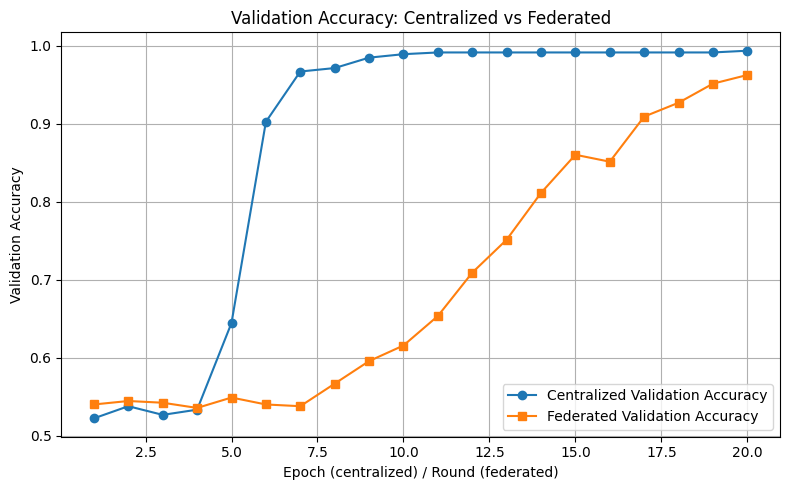

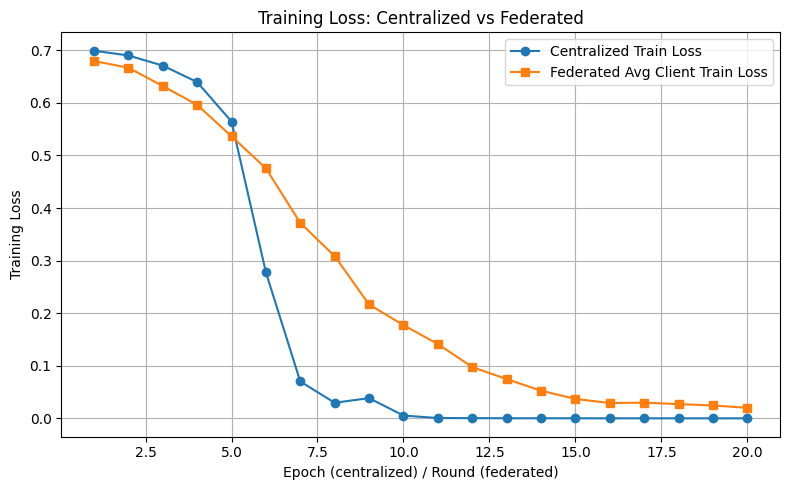

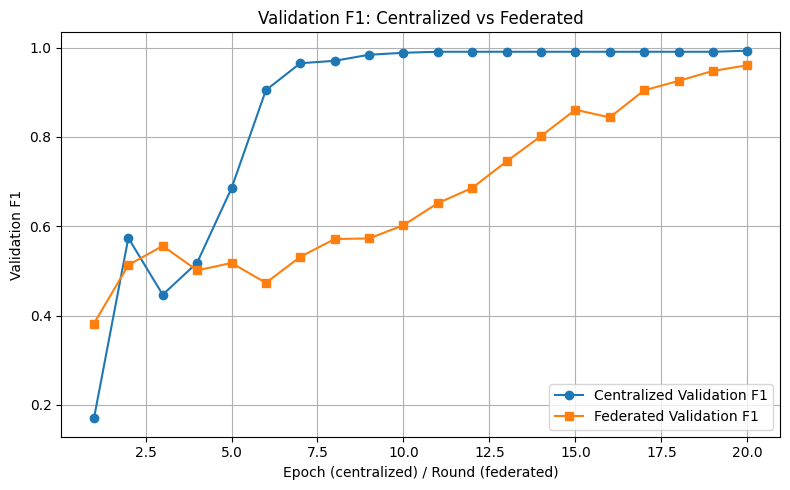

In [8]:
## LSTM with resume text + category

# ---------------------------
# Imports
# ---------------------------
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import random
import matplotlib.pyplot as plt

df = pd.read_csv("synthetic_resumes_balanced.csv")
job_categories = df['job_category'].unique().tolist()
job2idx = {j:i for i,j in enumerate(job_categories)}
df['job_idx'] = df['job_category'].map(job2idx)

def tokenize(text):
    return text.lower().split()

all_tokens = [tok for text in df['resume_text'] for tok in tokenize(text)]
vocab = {tok: idx+1 for idx, tok in enumerate(set(all_tokens))}  # 0=padding
UNK_IDX = len(vocab)+1
VOCAB_SIZE = UNK_IDX+1

def encode(text):
    return [vocab.get(tok, UNK_IDX) for tok in tokenize(text)]

class ResumeDataset(Dataset):
    def __init__(self, texts, cat_indices, labels):
        self.texts = [torch.tensor(encode(t), dtype=torch.long) for t in texts]
        self.cats = torch.tensor(cat_indices, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.texts[idx], self.cats[idx], self.labels[idx]

def collate_fn(batch):
    texts, cats, labels = zip(*batch)
    texts_padded = nn.utils.rnn.pad_sequence(texts, batch_first=True, padding_value=0)
    return texts_padded, torch.tensor(cats, dtype=torch.long), torch.tensor(labels, dtype=torch.float32)

dataset = ResumeDataset(df['resume_text'], df['job_idx'], df['label'])

# Train/val/test split
n = len(dataset)
train_size = int(0.7*n)
val_size = int(0.15*n)
test_size = n - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size],
                                                        generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=32, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, collate_fn=collate_fn)

# LSTM Model
class ResumeLSTM(nn.Module):
    def __init__(self, vocab_size, num_categories, embed_dim=128, cat_embed_dim=32, hidden_dim=256, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.cat_embedding = nn.Embedding(num_categories, cat_embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim*2 + cat_embed_dim, 1)

    def forward(self, texts, cat_idx):
        x = self.embedding(texts)
        lstm_out, _ = self.lstm(x)
        h = lstm_out.mean(dim=1)  # mean pooling
        cat_emb = self.cat_embedding(cat_idx)
        h = torch.cat([h, cat_emb], dim=1)
        h = self.dropout(h)
        logits = self.fc(h).squeeze(-1)
        return logits  # use BCEWithLogitsLoss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def eval_model(model, loader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for texts, cats, y in loader:
            texts, cats = texts.to(device), cats.to(device)
            logits = model(texts, cats)
            y_hat = torch.sigmoid(logits).cpu()
            y_true.extend(y.numpy())
            y_pred.extend((y_hat.numpy()>0.5).astype(int))
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0)
    }

# Centralized training (track metrics)
model = ResumeLSTM(VOCAB_SIZE, num_categories=len(job_categories)).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'max', factor=0.5, patience=2)

EPOCHS = 20

cent_train_losses = []
cent_val_accuracies = []
cent_val_f1s = []

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    total_samples = 0
    for texts, cats, y in train_loader:
        texts, cats, y = texts.to(device), cats.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(texts, cats)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        batch_sz = texts.size(0)
        train_loss += loss.item() * batch_sz
        total_samples += batch_sz
    train_loss = train_loss / total_samples
    cent_train_losses.append(train_loss)

    val_metrics = eval_model(model, val_loader)
    cent_val_accuracies.append(val_metrics['accuracy'])
    cent_val_f1s.append(val_metrics['f1'])

    scheduler.step(val_metrics['f1'])
    print(f"Epoch {epoch+1}/{EPOCHS} - train_loss: {train_loss:.4f} - val_f1: {val_metrics['f1']:.4f} - val_acc: {val_metrics['accuracy']:.4f}")

test_metrics = eval_model(model, test_loader)
print("Centralized test metrics:", test_metrics)

# FedAvg training
num_clients = 5
client_lengths = [len(train_dataset)//num_clients]*num_clients
for i in range(len(train_dataset) % num_clients):
    client_lengths[i] += 1
client_datasets = random_split(train_dataset, client_lengths,
                               generator=torch.Generator().manual_seed(42))

def federated_train(model_fn, client_datasets, rounds=10, local_epochs=3, lr=5e-3):
    global_model = model_fn().to(device)
    criterion = nn.BCEWithLogitsLoss()

    fed_train_losses = []
    fed_val_accuracies = []
    fed_val_f1s = []

    for r in range(rounds):
        client_states = []
        client_sample_counts = []
        client_losses = []

        for cd in client_datasets:
            client_model = model_fn().to(device)
            client_model.load_state_dict(global_model.state_dict())
            optimizer = torch.optim.AdamW(client_model.parameters(), lr=lr, weight_decay=1e-4)
            loader = DataLoader(cd, batch_size=32, shuffle=True, collate_fn=collate_fn)

            client_train_loss = 0.0
            client_samples = 0

            for _ in range(local_epochs):
                client_model.train()
                for texts, cats, y in loader:
                    texts, cats, y = texts.to(device), cats.to(device), y.to(device)
                    optimizer.zero_grad()
                    logits = client_model(texts, cats)
                    loss = criterion(logits, y)
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(client_model.parameters(), 5.0)
                    optimizer.step()

                    bsz = texts.size(0)
                    client_train_loss += loss.item() * bsz
                    client_samples += bsz

            avg_client_loss = client_train_loss / client_samples if client_samples > 0 else 0.0
            client_losses.append(avg_client_loss)
            client_sample_counts.append(len(cd))

            client_states.append({k:v.cpu() for k,v in client_model.state_dict().items()})

        total_samples = sum(client_sample_counts)
        new_state = {}
        for k in client_states[0].keys():
            new_state[k] = sum(client_states[i][k] * (client_sample_counts[i] / total_samples)
                               for i in range(len(client_states)))
        global_model.load_state_dict(new_state)

        avg_round_train_loss = sum(client_losses) / len(client_losses) if len(client_losses) > 0 else 0.0
        fed_train_losses.append(avg_round_train_loss)

        val_metrics = eval_model(global_model, val_loader)
        fed_val_accuracies.append(val_metrics['accuracy'])
        fed_val_f1s.append(val_metrics['f1'])

        print(f"Round {r+1}/{rounds} - avg_client_train_loss: {avg_round_train_loss:.4f} - val_f1: {val_metrics['f1']:.4f} - val_acc: {val_metrics['accuracy']:.4f}")

    return global_model, fed_train_losses, fed_val_accuracies, fed_val_f1s

def model_factory():
    return ResumeLSTM(VOCAB_SIZE, num_categories=len(job_categories))

fed_model, fed_train_losses, fed_val_accuracies, fed_val_f1s = federated_train(model_factory, client_datasets, rounds=20, local_epochs=3)
fed_test_metrics = eval_model(fed_model, test_loader)
print("FedAvg test metrics:", fed_test_metrics)

# ---------------------------
# Plotting: 3 separate graphs (Accuracy, Training Loss, F1)
# - Centralized: x = epochs (1..EPOCHS)
# - Federated: x = rounds (1..rounds)
# ---------------------------
cent_x = list(range(1, EPOCHS+1))
fed_x = list(range(1, len(fed_val_accuracies)+1))

# 1) Accuracy plot
plt.figure(figsize=(8,5))
plt.plot(cent_x, cent_val_accuracies, marker='o', label='Centralized Validation Accuracy')
plt.plot(fed_x, fed_val_accuracies, marker='s', label='Federated Validation Accuracy')
plt.xlabel('Epoch (centralized) / Round (federated)')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy: Centralized vs Federated')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 2) Training Loss plot
plt.figure(figsize=(8,5))
plt.plot(cent_x, cent_train_losses, marker='o', label='Centralized Train Loss')
plt.plot(fed_x, fed_train_losses, marker='s', label='Federated Avg Client Train Loss')
plt.xlabel('Epoch (centralized) / Round (federated)')
plt.ylabel('Training Loss')
plt.title('Training Loss: Centralized vs Federated')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3) F1 plot
plt.figure(figsize=(8,5))
plt.plot(cent_x, cent_val_f1s, marker='o', label='Centralized Validation F1')
plt.plot(fed_x, fed_val_f1s, marker='s', label='Federated Validation F1')
plt.xlabel('Epoch (centralized) / Round (federated)')
plt.ylabel('Validation F1')
plt.title('Validation F1: Centralized vs Federated')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



--- Preparing for Non-IID Federated Training ---

--- Non-IID Client Data Distribution (Dirichlet α=0.9) ---
Client 0: Total Samples=341 | Distribution={'Product Manager': 126, 'Software Engineer': 99, 'Designer': 116}
Client 1: Total Samples=536 | Distribution={'Product Manager': 170, 'Software Engineer': 177, 'Designer': 189}
Client 2: Total Samples=542 | Distribution={'Product Manager': 188, 'Software Engineer': 181, 'Designer': 173}
Client 3: Total Samples=215 | Distribution={'Product Manager': 75, 'Software Engineer': 59, 'Designer': 81}
Client 4: Total Samples=466 | Distribution={'Product Manager': 138, 'Software Engineer': 187, 'Designer': 141}
----------------------------------------------------------

Starting Federated Training on NON-IID data...
Round 1/20 - avg_client_train_loss: 0.6566 - val_f1: 0.4310 - val_acc: 0.4778
Round 2/20 - avg_client_train_loss: 0.6317 - val_f1: 0.4989 - val_acc: 0.5044
Round 3/20 - avg_client_train_loss: 0.5689 - val_f1: 0.4612 - val_acc: 0.506

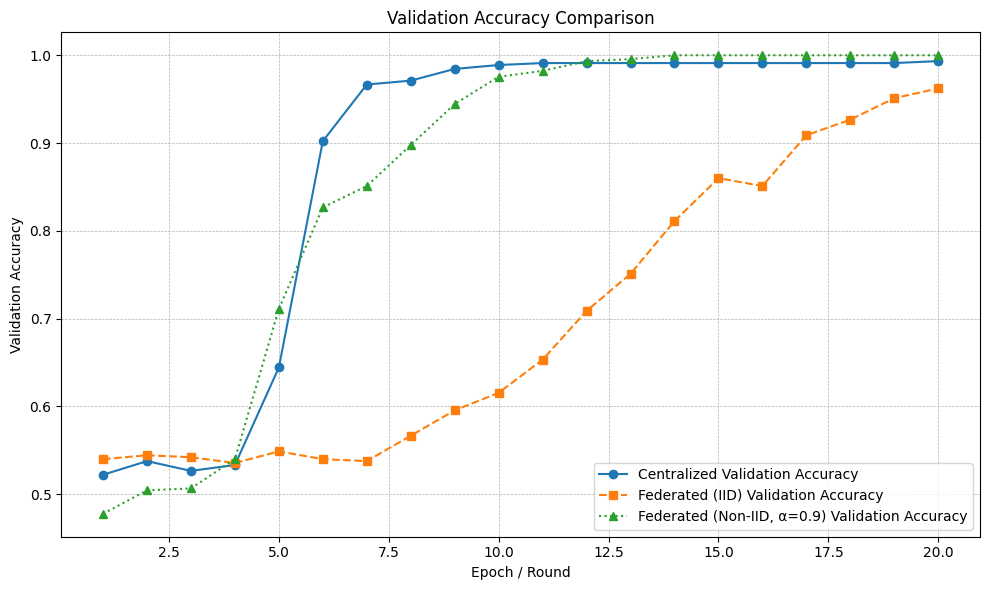

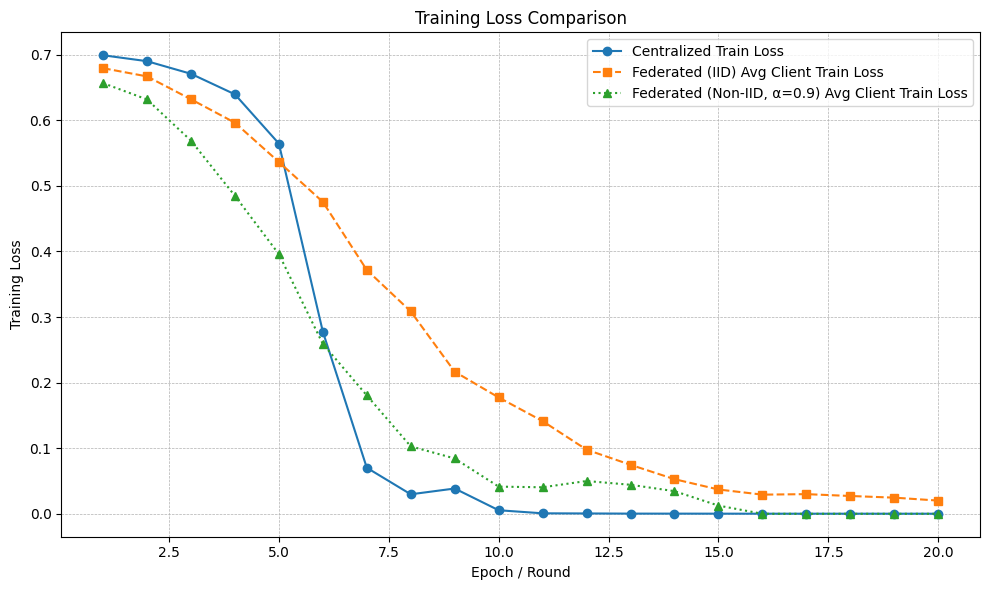

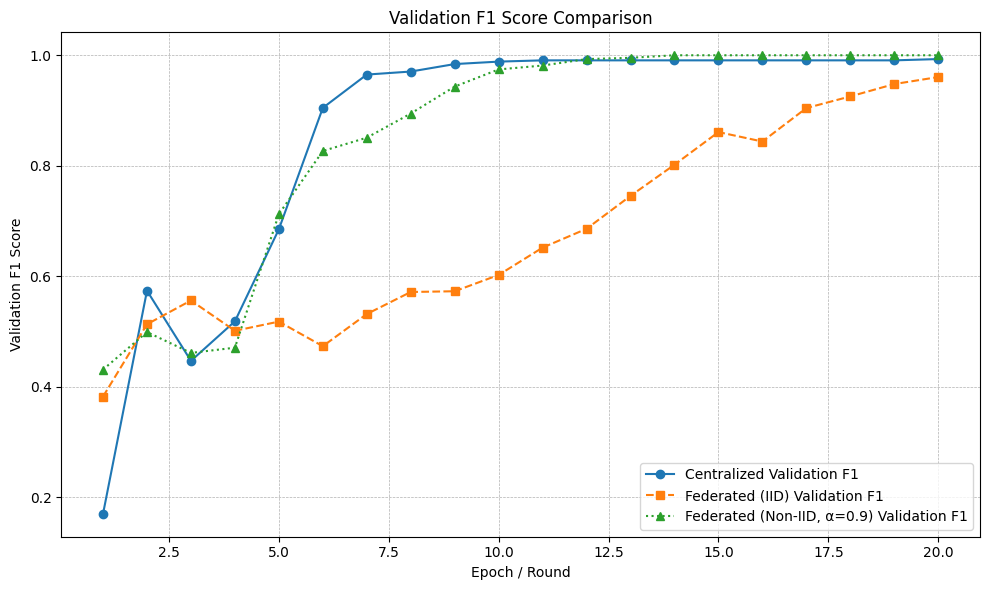

In [9]:
# NON-IID Data Partitioning using Dirichlet Distribution (CORRECTED)

import numpy as np
from torch.utils.data import Subset

print("\n--- Preparing for Non-IID Federated Training ---")

np.random.seed(42)

num_clients = 5
alpha = 0.9
num_classes = len(job_categories)  # 3 Job Categories

train_indices = train_dataset.indices
train_labels = np.array([train_dataset.dataset.cats[i] for i in train_indices])

client_indices = [[] for _ in range(num_clients)]

# Dirichlet distribution
for k in range(num_classes):
    idx_k = np.where(train_labels == k)[0]
    np.random.shuffle(idx_k)

    proportions = np.random.dirichlet(np.repeat(alpha, num_clients))

    proportions = (np.cumsum(proportions) * len(idx_k)).astype(int)[:-1]

    client_splits = np.split(idx_k, proportions)
    for i in range(num_clients):
        client_indices[i].extend(client_splits[i])

client_datasets_non_iid = [Subset(train_dataset, indices) for indices in client_indices]

# Print the distribution ---
print("\n--- Non-IID Client Data Distribution (Dirichlet α=0.9) ---")
for i, client_ds in enumerate(client_datasets_non_iid):
    labels = [train_dataset.dataset.cats[idx] for idx in client_ds.indices]
    class_counts = {job_categories[j]: 0 for j in range(num_classes)}
    for label in labels:
        class_counts[job_categories[label.item()]] += 1
    print(f"Client {i}: Total Samples={len(client_ds)} | Distribution={class_counts}")
print("----------------------------------------------------------\n")

print("Starting Federated Training on NON-IID data...")

fed_model_non_iid, fed_train_losses_non_iid, fed_val_accuracies_non_iid, fed_val_f1s_non_iid = federated_train(
    model_factory,
    client_datasets_non_iid,
    rounds=20,
    local_epochs=3,
    lr=5e-3
)

fed_test_metrics_non_iid = eval_model(fed_model_non_iid, test_loader)
print("\nFedAvg (Non-IID α=0.9) Final Test Metrics:", fed_test_metrics_non_iid)


print("\n--- Generating Comparison Plots ---")

cent_x = list(range(1, EPOCHS + 1))
fed_x = list(range(1, len(fed_val_accuracies) + 1))

# 1) Validation Accuracy Plot
plt.figure(figsize=(10, 6))
plt.plot(cent_x, cent_val_accuracies, marker='o', linestyle='-', label='Centralized Validation Accuracy')
plt.plot(fed_x, fed_val_accuracies, marker='s', linestyle='--', label='Federated (IID) Validation Accuracy')
plt.plot(fed_x, fed_val_accuracies_non_iid, marker='^', linestyle=':', label='Federated (Non-IID, α=0.9) Validation Accuracy')
plt.xlabel('Epoch / Round')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy Comparison')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

# 2) Training Loss Plot
plt.figure(figsize=(10, 6))
plt.plot(cent_x, cent_train_losses, marker='o', linestyle='-', label='Centralized Train Loss')
plt.plot(fed_x, fed_train_losses, marker='s', linestyle='--', label='Federated (IID) Avg Client Train Loss')
plt.plot(fed_x, fed_train_losses_non_iid, marker='^', linestyle=':', label='Federated (Non-IID, α=0.9) Avg Client Train Loss')
plt.xlabel('Epoch / Round')
plt.ylabel('Training Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

# 3) Validation F1 Score Plot
plt.figure(figsize=(10, 6))
plt.plot(cent_x, cent_val_f1s, marker='o', linestyle='-', label='Centralized Validation F1')
plt.plot(fed_x, fed_val_f1s, marker='s', linestyle='--', label='Federated (IID) Validation F1')
plt.plot(fed_x, fed_val_f1s_non_iid, marker='^', linestyle=':', label='Federated (Non-IID, α=0.9) Validation F1')
plt.xlabel('Epoch / Round')
plt.ylabel('Validation F1 Score')
plt.title('Validation F1 Score Comparison')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()